# Experiment 4: PCA

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Dataset

In [2]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Check Dataset Shape

In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (150, 6)


# Check Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


# Check Missing Values

In [6]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


# Statistical Description

In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Select Features

In [8]:
X = df[
    [
        'SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm'
    ]
]

y = df['Species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


# Standardization

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.02184904  1.26346019 -1.3412724  -1.31297673]]


# Check Standardized Data

In [10]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


# Apply PCA

In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (150, 4)
Reduced shape: (150, 2)


# Display PCA Data

In [12]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df['Species'] = y.values

pca_df.head()

,PC1,PC2,Species
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


# Explained Varieance

In [13]:
print("Explained Variance Ratio:")

for i, value in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {value:.4f}")

Explained Variance Ratio:
PC1: 0.7277
PC2: 0.2303


# Total Varieance Retained

In [14]:
total_variance = pca.explained_variance_ratio_.sum()

print("Total Variance Retained:",
      total_variance)

print("Percentage of Variance Retained:",
      total_variance * 100, "%")

Total Variance Retained: 0.9580097536148195
Percentage of Variance Retained: 95.80097536148196 %


# Eigenvalues

In [15]:
print("Eigenvalues:")
print(pca.explained_variance_)

Eigenvalues:
[2.93035378 0.92740362]


# Principle Components

In [16]:
print("Principal Component Matrix:")
print(pca.components_)

Principal Component Matrix:
[[ 0.52237162 -0.26335492  0.58125401  0.56561105]
 [ 0.37231836  0.92555649  0.02109478  0.06541577]]


# PCA Visualization

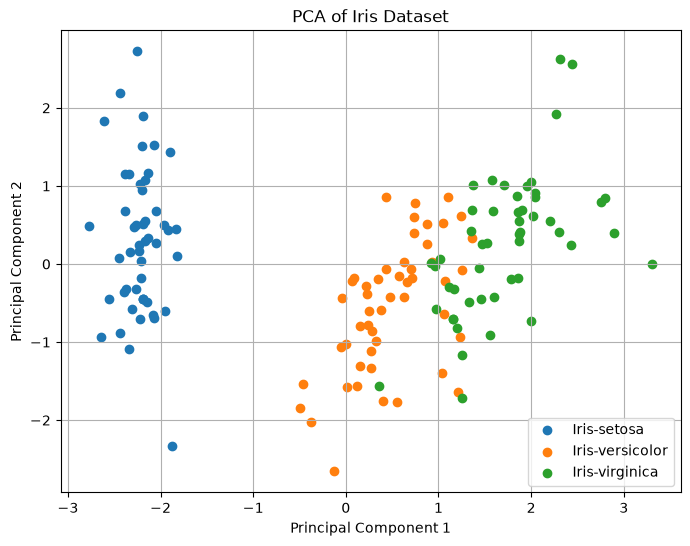

In [17]:
plt.figure(figsize=(8, 6))

species = y.unique()

for species_name in species:
    subset = pca_df[pca_df['Species'] == species_name]

    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=species_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.grid()

plt.show()

# Screen Plot

In [18]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print("Explained Variance:")
print(explained_variance)

Explained Variance:
[0.72770452 0.23030523 0.03683832 0.00515193]


# Screen Graph

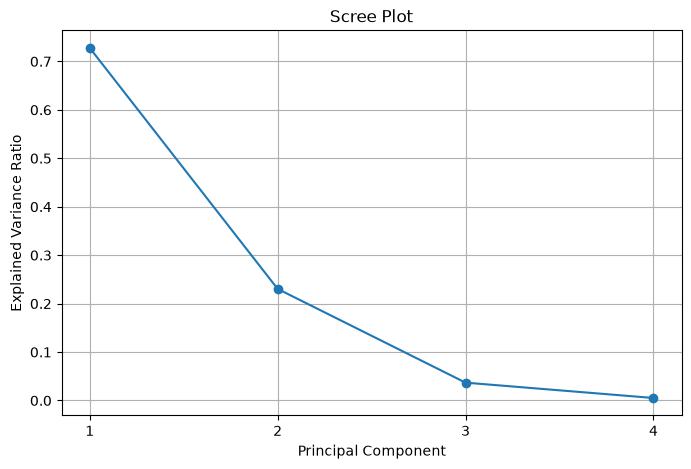

In [19]:
plt.figure(figsize=(8, 5))

components = range(1, 5)

plt.plot(
    components,
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(components)
plt.grid()

plt.show()

# Cumulative Variance

In [20]:
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

print("Cumulative Explained Variance:")

for i, value in enumerate(cumulative_variance):
    print(
        f"First {i+1} component(s): "
        f"{value:.4f} "
        f"({value*100:.2f}%)"
    )

Cumulative Explained Variance:
First 1 component(s): 0.7277 (72.77%)
First 2 component(s): 0.9580 (95.80%)
First 3 component(s): 0.9948 (99.48%)
First 4 component(s): 1.0000 (100.00%)


# Final Comparison

In [21]:
print("========== PCA RESULT ==========")

print("Original number of features:",
      X.shape[1])

print("Number of PCA components:",
      X_pca.shape[1])

print("Variance retained:",
      round(
          pca.explained_variance_ratio_.sum() * 100,
          2
      ),
      "%")

========== PCA RESULT ==========
Original number of features: 4
Number of PCA components: 2
Variance retained: 95.8 %
